# **Tennis Stroke MultiClassification: Model Development Version 2**

## **1. Imports**

In [82]:
import torch
from torch import nn
import torch.nn.functional as F
import albumentations as A
from albumentations import ToTensorV2
from pathlib import Path
import random
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, ConcatDataset
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import StepLR
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from collections import defaultdict
import cv2
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

device = 'mps' if torch.backends.mps.is_available() else 'cpu'
plt.rcParams['font.family'] = 'Serif' 

## **2. Data Processing and Visualizations**

In [39]:
def walkthrough_data(dir_path: str) -> dict:
    """Walk through dir_path returning its contents. Also keeps track of number of images per class."""
    splits = {
        "train": defaultdict(int),
        "test": defaultdict(int)
    }
    for curr_dir, dirnames, filenames in os.walk(dir_path):
        print(f"{len(dirnames)} directories and {len(filenames)} images in {curr_dir}")

        if len(filenames) > 0: 
            class_name = os.path.basename(curr_dir)

            if "train" in curr_dir.lower():
                splits["train"][class_name] += len(filenames)
            elif "test" in curr_dir.lower():
                splits["test"][class_name] += len(filenames)
    return splits

class_counts = walkthrough_data('dataset')
class_counts

2 directories and 0 images in dataset
4 directories and 0 images in dataset/train_set
0 directories and 375 images in dataset/train_set/forehand
0 directories and 375 images in dataset/train_set/backhand
0 directories and 375 images in dataset/train_set/serve
0 directories and 375 images in dataset/train_set/ready_position
4 directories and 0 images in dataset/test_set
0 directories and 125 images in dataset/test_set/forehand
0 directories and 125 images in dataset/test_set/backhand
0 directories and 125 images in dataset/test_set/serve
0 directories and 125 images in dataset/test_set/ready_position


{'train': defaultdict(int,
             {'forehand': 375,
              'backhand': 375,
              'serve': 375,
              'ready_position': 375}),
 'test': defaultdict(int,
             {'forehand': 125,
              'backhand': 125,
              'serve': 125,
              'ready_position': 125})}

In [40]:
image_path = Path("dataset")

train_dir = image_path / "train_set"
test_dir = image_path / "test_set"

train_dir, test_dir

(PosixPath('dataset/train_set'), PosixPath('dataset/test_set'))

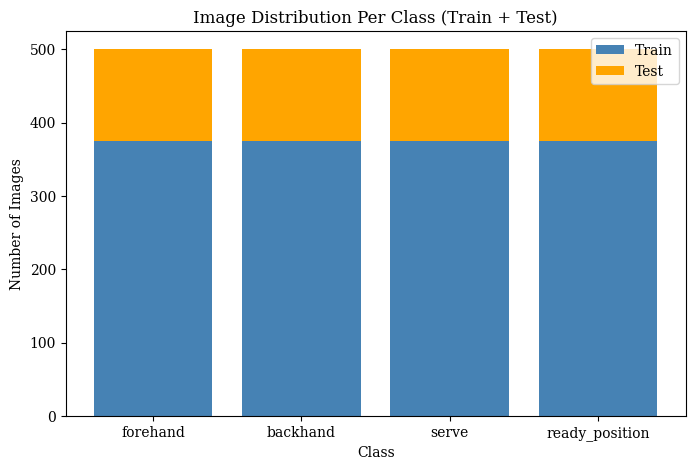

In [41]:
train_counts = class_counts['train']
test_counts = class_counts['test']

classes = list(train_counts.keys())
train_values = [train_counts[c] for c in classes]
test_values = [test_counts[c] for c in classes]

plt.figure(figsize = (8,5))
plt.bar(classes, train_values, label = "Train", color = "steelblue")
plt.bar(classes, test_values, bottom = train_values, label = "Test", color = "orange")

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Image Distribution Per Class (Train + Test)")
plt.legend()

plt.show()

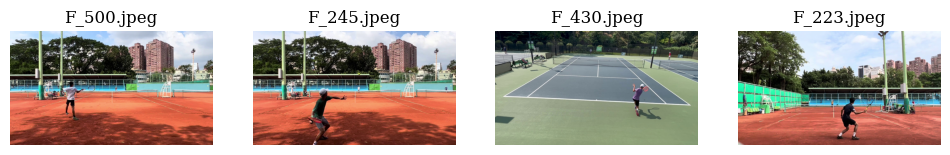

In [42]:
def show_random_images(folder_path: str, num_images: int = 4) -> None:
    files = [f for f in os.listdir(folder_path) if f.lower().endswith((".jpg", ".png", ".jpeg"))]
    
    sample_files = random.sample(files, num_images)

    plt.figure(figsize = (12, 4))
    for i, filename in enumerate(sample_files):
        img = Image.open(os.path.join(folder_path, filename))
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img)
        plt.title(filename[:15])
        plt.axis("off")
    plt.show()

show_random_images("dataset/train_set/forehand")

## **3. Data Loading and Transformations**

In [61]:
def center_crop_square(image, **kwargs):
    h, w = image.shape[:2]
    min_dim = min(h, w)
    top = (h - min_dim) // 2
    left = (w - min_dim) // 2
    return image[top : top + min_dim, left:left + min_dim]

In [68]:
# Transformation Definitions
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_transforms_1 = A.Compose([
    A.RandomBrightnessContrast(
        brightness_limit = 0.1,       
        contrast_limit = 0.1,
        p = 0.5
    ),
    A.HueSaturationValue(
        hue_shift_limit = 10,
        sat_shift_limit = 10,
        val_shift_limit = 10, 
        p = 0.5
    ),
    A.OneOf([ 
        A.GaussianBlur(blur_limit = (3, 5), p = 1.0),
        A.Sharpen(alpha = (0.1, 0.3), lightness = (0.7, 1.0), p = 1.0),
    ], p = 0.4),
    A.Resize(224, 224),
    A.Normalize(mean = mean,
                std = std),
    ToTensorV2()
])

train_transforms_2 = A.Compose([
    A.Lambda(image = center_crop_square),
    A.HorizontalFlip(p = 1),
    A.RandomBrightnessContrast(
        brightness_limit = 0.1,       
        contrast_limit = 0.1,
        p = 0.5
    ),
    A.HueSaturationValue(
        hue_shift_limit = 10,
        sat_shift_limit = 10,
        val_shift_limit = 10, 
        p = 0.5
    ),
    A.OneOf([ 
        A.GaussianBlur(blur_limit = (3, 5), p = 1.0),
        A.Sharpen(alpha = (0.1, 0.3), lightness = (0.7, 1.0), p = 1.0),
    ], p = 0.4),
    A.Resize(224, 224),
    A.Normalize(mean = mean,
                std = std),
    ToTensorV2()
])

train_transforms_3 = A.Compose([
    A.RandomBrightnessContrast(
        brightness_limit = 0.1,       
        contrast_limit = 0.1,
        p = 0.5
    ),
    A.HueSaturationValue(
        hue_shift_limit = 10,
        sat_shift_limit = 10,
        val_shift_limit = 10, 
        p = 0.5
    ),
    A.OneOf([ 
        A.GaussianBlur(blur_limit = (3, 5), p = 1.0),
        A.Sharpen(alpha = (0.1, 0.3), lightness = (0.7, 1.0), p = 1.0),
    ], p = 0.4),
    A.Affine(
        scale = (1 - 0.5, 1 + 0.5),    
        translate_percent = (0.15, 0.15),       
        fit_output = False,
        border_mode = 0,
        p = 1
    ),
    A.Resize(224, 224),
    A.Normalize(mean = mean,
                std = std),
    ToTensorV2()
])

train_transforms_4 = A.Compose([
    A.Lambda(image = center_crop_square),
    A.HorizontalFlip(p = 1),
    A.RandomBrightnessContrast(
        brightness_limit = 0.1,       
        contrast_limit = 0.1,
        p = 0.5
    ),
    A.HueSaturationValue(
        hue_shift_limit = 10,
        sat_shift_limit = 10,
        val_shift_limit = 10, 
        p = 0.5
    ),
    A.OneOf([ 
        A.GaussianBlur(blur_limit = (3, 5), p = 1.0),
        A.Sharpen(alpha = (0.1, 0.3), lightness = (0.7, 1.0), p = 1.0),
    ], p = 0.4),
    A.Affine(
        scale = (1 - 0.5, 1 + 0.5),    
        translate_percent = (0.15, 0.15),       
        fit_output = False,
        border_mode = 0,
        p = 1
    ),
    A.Resize(224, 224),
    A.Normalize(mean = mean,
                std = std),
    ToTensorV2()
])

test_transforms = A.Compose([
    A.Lambda(image = center_crop_square), 
    A.Resize(224, 224),
    A.Normalize(mean = mean, std = std),
    ToTensorV2()
])

class AlbumentationsAdapter:
    def __init__(self, aug):
        self.aug = aug
    def __call__(self, image):
        image = np.array(image)  # PIL → NumPy
        return self.aug(image=image)["image"]

In [69]:
train_data_1 = datasets.ImageFolder(root = train_dir, transform = AlbumentationsAdapter(train_transforms_1))
train_data_2 = datasets.ImageFolder(root = train_dir, transform = AlbumentationsAdapter(train_transforms_2))
train_data_3 = datasets.ImageFolder(root = train_dir, transform = AlbumentationsAdapter(train_transforms_3))
train_data_4 = datasets.ImageFolder(root = train_dir, transform = AlbumentationsAdapter(train_transforms_4))


train_data = ConcatDataset([
    train_data_1,
    train_data_2,
    train_data_3,
    train_data_4
])

test_data = datasets.ImageFolder(
    root = test_dir,
    transform = test_transforms
)

train_loader = DataLoader(
    dataset = train_data,
    batch_size = 32,
    shuffle = True,
    num_workers = 0,
    pin_memory = True,
)

test_loader = DataLoader(
    dataset = test_data,
    batch_size = 32,
    shuffle = False,
    num_workers = 0,
    pin_memory = True
)

len(train_loader), len(test_loader)

(188, 16)

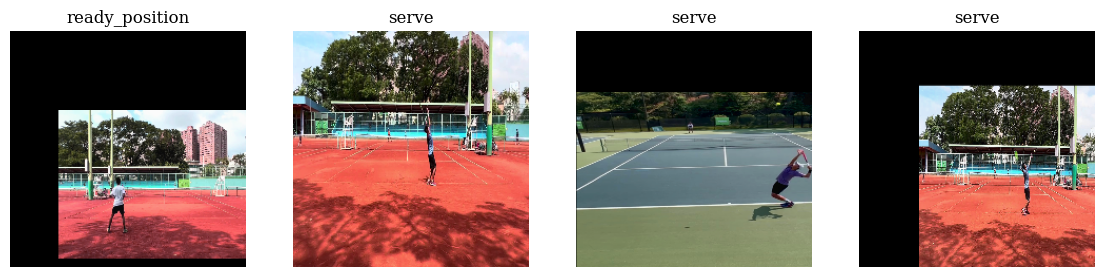

In [77]:
#Visualize some samples from the dataloader
def unnormalize(img_tensor: torch.Tensor) -> Image.Image:
    img = img_tensor.permute(1, 2, 0).cpu().numpy()  
    img = (img * std) + mean           
    img = np.clip(img, 0, 1)      
    return img

def visualize_batch(data_loader: torch.utils.data.DataLoader, class_names = train_data_1.classes, num_images = 4):
    images, labels = next(iter(data_loader))

    plt.figure(figsize = (14, 4))
    for i in range(num_images):
        img = unnormalize(images[i])
        label = class_names[labels[i]]

        plt.subplot(1, num_images, i + 1)
        plt.imshow(img)
        plt.title(label)
        plt.axis("off")

    plt.show()

visualize_batch(train_loader)

In [78]:
class_to_idx = train_data.datasets[0].class_to_idx
print(class_to_idx)

{'backhand': 0, 'forehand': 1, 'ready_position': 2, 'serve': 3}


## **4. Initialize Model, Optimizer, and Loss Function**

In [80]:
class FocalLoss(nn.Module):
    """
    Multiclass Focal Loss implementation.
    Works with softmax logits (for CrossEntropy-style classification).
    """
    def __init__(self, alpha: float = 0.25, gamma: float = 2.0):
        """
        Args:
            alpha: Weighting factor for class imbalance (0 < alpha <= 1)
            gamma: Focusing parameter
        """
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Args:
            logits: model outputs before softmax, shape (N, C)
            targets: ground-truth class indices
        """
        # Logits to probabilities
        probs = F.softmax(logits, dim = 1)
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)

        # Compute focal loss
        focal_term = (1 - pt) ** self.gamma
        loss = -self.alpha * focal_term * torch.log(pt + 1e-8)

        return loss.mean()

In [83]:
model = models.convnext_tiny(weights = 'IMAGENET1K_V1')
in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, 4)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /Users/liu_michael/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:17<00:00, 6.55MB/s] 


In [85]:
def accuracy_function(y_true: torch.Tensor, y_pred_logits: torch.Tensor) -> float:
    """
    Computes accuracy for multiclass tasks.
    Args:
        y_true: Ground truth labels
        y_pred_logits: Model logit outputs
    """
    preds = torch.round(y_pred_logits)
    return (preds == y_true).float().mean().item() * 100

In [86]:
adam_optimizer = torch.optim.Adam(params = model.parameters(), lr = 1e-4)
loss_fn = FocalLoss(alpha = [1, 1, 1, 1])

# **5. Training and Testing Loop**